# $B^\pm \to \pi^\pm\pi^\pm\pi^\mp$ — réplica de um ajuste CP do Laura++

Este notebook reconstrói, com o `dalitzplotfitter`, o mesmo modelo isobárico CP usado em um
ajuste real do Laura++ (`LauCPFitModel`) para $B^\pm\to\pi^\pm\pi^\pm\pi^\mp$, usando exatamente
os mesmos dados, mapa de aceitância (ACC) e histograma de background (qqbar) já produzidos para
aquele ajuste, e compara os parâmetros convergidos com o log do Laura++.

Fontes de referência (fora do repositório, não versionadas):

- configuração do gerador/ajuste: `GenFit3piCP_R2_415489.cc`
- log do ajuste convergido: `GenFit3piCP_fit_415489.log`
- dados, ACC e background: `.../inputs/` (mesma pasta do `.cc` acima)

## Convenções extraídas do `.cc`/log do Laura++

- `LauDaughters("B+", "pi+", "pi+", "pi-", squareDP=kTRUE)`: as duas partículas idênticas são os
  índices `(0, 1)` (`pi+`, `pi+`); o índice `2` é o `pi-` bachelor. Isso é exatamente a mesma
  convenção de partículas já validada em
  `notebooks/benchmark/paper_isobar_benchmark_squaredp_01_laura_toys.ipynb` para o mesmo canal:
  `pair=(2, 0)` para as ressonâncias (orientação angular) e `normalization_pair=(0, 1)` para a
  quadratura Square-Dalitz (o par idêntico).
- Todas as 9 ressonâncias usam `resPairAmpInt=2`, i.e. `pair=(2, 0)` no nosso `Resonance`.
- Massas/larguras/spins de partida vêm da tabela de ressonâncias padrão do Laura++
  (`LauResonanceMaker.cc`, verificado linha a linha contra os valores de partida impressos no log);
  os raios de Blatt-Weisskopf (`Parent`, `Light`, `Charmonium`) são todos fixos em 4.0 GeV⁻¹, como
  no `.cc` (`resMaker.setDefaultBWRadius(..., 4.0)` + `fixBWRadius(..., kTRUE)`).
- Coeficientes CP cartesianos (`LauCartesianCPCoeffSet`) mapeiam diretamente para `CPRealImag(x, y,
  dx, dy)` com `c_q = (x + q dx) + i(y + q dy)`, a mesma convenção documentada em
  `docs/cp_coefficients.md`. `rho0(770)` é a referência de fase/escala global do modelo (`x=1`,
  `y=0`, `dy=0` fixos; só `dx` flutua) — os demais 8 componentes têm os quatro parâmetros livres.
- `sigma0` usa o tipo `LauAbsResonance::Pole` do Laura++ (`LauPoleRes`). A álgebra de
  `LauPoleRes::resAmp` (`mpole=(m0-iΓ)`, amplitude `=1/(mpole²-m²)` calculada via `1/z =
  conj(z)/|z|²`) foi verificada e é exatamente a convenção já implementada em `SigmaPole` deste
  pacote (`docs/lineshapes.md`), não uma parametrização nova.
- O sinal (`signalAsym`) do `.cc` é criado mas **não é usado**: o comentário do próprio `.cc` e o
  código-fonte do Laura++ (`LauCPFitModel::getTotEvtLikelihood`) mostram que ele só entra na
  verossimilhança quando o DP *não* está no ajuste (`useDP()==kFALSE`); aqui a assimetria de sinal
  vem inteiramente do modelo isobárico via a normalização conjunta `I_plus`/`I_minus`
  (`CPJointNLL` padrão, sem `YieldAsymmetry` — ver `docs/cp_coefficients.md`).
- O background `kpipibkg` (`bkg_kpipi_histo.root`, histograma `hbkg`, **o mesmo** para B+ e B-)
  existe na configuração mas tem **yield fixo em zero** (`nBgkpipiEvents = 95120*.0`, confirmado
  também no log final: `kpipibkgEvents 0.00000e+00 fixed` do início ao fim do ajuste) — ou seja,
  `0 x densidade = 0` para todo evento, e o componente é matematicamente inerte no ajuste
  original. Ainda assim ele é carregado e registrado abaixo (`yield_` fixo em zero), por fidelidade
  estrutural ao `.cc`: dessa forma o modelo replicado tem exatamente os mesmos três componentes de
  background que o Laura++ registra (`qqbar`, `kpipibkg`), e não apenas os que de fato contribuem.
  A assimetria `kpipibkgEventsAsym = 0.03` (também fixa no `.cc`) é igualmente inerte por estar
  multiplicada por um yield nulo; é aplicada mesmo assim, como constante, só por completude.
- O background `qqbar` tem uma pequena assimetria de yield fixa,
  `qqbarEventsAsym = -0.0078` (fixa), aplicada via `bkgndEvents = N_bkg * 0.5 * (1 - carga_evento *
  asym)` no `LauCPFitModel.cc` — exatamente a convenção `YieldAsymmetry` deste pacote
  (`N_plus=(N/2)(1-A)`, `N_minus=(N/2)(1+A)`), mas aplicada ao *background*, não ao sinal.
  o método `with_charge_asymmetry` reproduz isso normalizando cada forma
  pela sua própria integral pós-veto na *mesma* amostra de normalização/quadratura que a sessão de
  ajuste usa (não uma normalização "por fora", em numpy) e escalando por `(1 ∓ asym)`.
- **ACC e background não são adimensionais do mesmo jeito.** `Hacc_...` é uma eficiência (razão),
  usada como está. Já `hbkgbp`/`hbkgbm`/`hbkg` são uma densidade de probabilidade em `(m',
  theta')` (`Lau2DHistDPPdf`), e o restante do pipeline (a amostra de normalização, a
  verossimilhança) trabalha em `(s13, s23)`. Sem dividir pelo jacobiano `|d(s13,s23)/d(m',theta')|`
  (`square_dalitz_jacobian`), o valor lido do histograma é tratado como se já fosse uma densidade
  em `(s13, s23)`, o que introduz um viés de forma que varia ponto a ponto pelo Dalitz Plot — essa
  divisão é o que `SquareDalitzHistogramBackground.__call__` faz; as classes
  simples `SquareDalitzHistogramBackground`/`Efficiency` do pacote não assumem (documentado no
  próprio docstring do módulo de helpers: "the package's ordinary Square-Dalitz histogram classes
  return bin values and do not assume those values are a density in SDP").
- **Interpolação.** `useInterpolation=kTRUE` no Laura++ (`Lau2DHistDP::interpolateXY`) faz
  interpolação bilinear entre os *centros* dos bins (constante além do último centro), não busca
  pelo bin mais próximo. A opção `interpolation="linear"` reproduz
  exatamente essa regra e é usada tanto por `SquareDalitzHistogramEfficiency` quanto por `SquareDalitzHistogramBackground`.
- `useUpperHalf=kTRUE` para ACC e background: os histogramas cobrem só `theta' in [0, 0.5]`, i.e.
  `folded=True` em `SquareDalitzHistogramEfficiency`/`SquareDalitzHistogramBackground` (herdado por
  `SquareDalitzHistogramEfficiency`/`SquareDalitzHistogramBackground`).
- Veto de `D0`: `|m_13| , |m_23| in [1.74, 1.894]` GeV, i.e.
  `CompositeVeto(MassWindowVeto((0,2), 1.74, 1.894), MassWindowVeto((1,2), 1.74, 1.894))`.


In [1]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "dalitzplotfitter").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dalitzplotfitter import (
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    DecayChannel,
    DecayModel,
    GounarisSakurai,
    MassWindowVeto,
    Parameter,
    PhaseSpaceSample,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    RelativisticBreitWigner,
    Resonance,
    SigmaPole,
    ZemachP,
    enable_x64,
    read_root_histogram2d,
    read_root_tree,
)

enable_x64()


## Configuração

Caminhos e constantes extraídos diretamente de `GenFit3piCP_R2_415489.cc` e de
`LauResonanceMaker.cc` (Laura++ 3.8.0, `/home/juan-leite/Work/Laura-3.8.0/Laura++/src/`).

In [2]:
INPUTS = Path("/home/juan-leite/Work/data/fit415489_pipipinotav3_21-5--11h32m13s415489/inputs")

DATA_FILE = INPUTS / "data15161718_pipipi_LauNoSpike.root"
DATA_TREE = "fitTree"

ACC_FILE = INPUTS / "ACC_pipipi_15161718_NoSpike_prodAsy.root"
ACC_HIST_PLUS = "Hacc_pipipi_15161718_Plus"
ACC_HIST_MINUS = "Hacc_pipipi_15161718_Minus"

QQBAR_BKG_FILE = INPUTS / "Lau_3pi_BKG_pm_322_V2h_splot_normcut.root"
QQBAR_HIST_PLUS = "hbkgbp"
QQBAR_HIST_MINUS = "hbkgbm"

KPIPI_BKG_FILE = INPUTS / "bkg_kpipi_histo.root"
KPIPI_HIST = "hbkg"  # same histogram used for both B+ and B- in the .cc

D0_VETO_MIN_GEV = 1.74
D0_VETO_MAX_GEV = 1.894

N_TOTAL_EVENTS = 95110.0
SIGNAL_FRACTION = 0.8845
QQBAR_FRACTION = 0.1155
N_SIGNAL = N_TOTAL_EVENTS * SIGNAL_FRACTION
N_QQBAR = N_TOTAL_EVENTS * QQBAR_FRACTION
QQBAR_YIELD_ASYMMETRY = -0.0078  # qqbarEventsAsym, fixed

N_KPIPIBKG = 0.0  # nBgkpipiEvents = 95120*.0, fixed -- inert, kept only for structural fidelity
KPIPIBKG_YIELD_ASYMMETRY = 0.03  # kpipibkgEventsAsym, fixed -- inert since the yield above is 0

NORMALIZATION_RESOLUTION = 500  # Square-Dalitz Gauss-Legendre resolution per axis (Laura++ default is 1000)

print(f"N_signal = {N_SIGNAL:.3f}   N_qqbar = {N_QQBAR:.3f}   sum = {N_SIGNAL + N_QQBAR:.3f}")


N_signal = 84124.795   N_qqbar = 10985.205   sum = 95110.000


## Canais e veto

`DecayChannel` resolve massa do pai e das filhas via o pacote `particle`; usamos essas mesmas
massas para as coordenadas Square-Dalitz do ACC/background abaixo, garantindo consistência interna
com o que `DecayModel` usa.

In [3]:
PLUS_CHANNEL = DecayChannel("B+", ("pi+", "pi+", "pi-"))
MINUS_CHANNEL = DecayChannel("B-", ("pi-", "pi-", "pi+"))

MOTHER_MASS = PLUS_CHANNEL.parent_mass
DAUGHTER_MASSES = PLUS_CHANNEL.daughter_masses
SQDP_PAIR = (0, 1)  # the two identical pi+/pi-, per the sibling Laura-toy benchmark notebook
RESONANCE_PAIR = (2, 0)  # resPairAmpInt=2 for every resonance in the .cc

print("mother mass [GeV] =", MOTHER_MASS)
print("daughter masses [GeV] =", DAUGHTER_MASSES)

D0_VETO = CompositeVeto(
    MassWindowVeto((0, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
    MassWindowVeto((1, 2), D0_VETO_MIN_GEV, D0_VETO_MAX_GEV),
)


mother mass [GeV] = 5.2794099999999995
daughter masses [GeV] = (0.13957039000000002, 0.13957039000000002, 0.13957039000000002)


## Dados

`fitTree` tem `m12Sq`, `m13Sq`, `m23Sq` já na mesma convenção de índices `(pi+, pi+, pi-)` que
`DecayChannel` acima, então `s12<-m12Sq`, `s13<-m13Sq`, `s23<-m23Sq` sem reordenar. A carga é
`charge in {+1, -1}` com `+1` para `B+` (convenção verificada contra `LauCPFitModel::eventsToGenerate`,
`curEvtCharge_`, e já usada nos notebooks de CP existentes deste repositório).

O filtro por carga é feito com uma máscara booleana em Python, não com `cut=`: nesta instalação do
uproot (5.7.6) `cut=` não filtra nada (mesmo problema documentado em
`paper_isobar_benchmark_squaredp_01_laura_toys.ipynb`).

In [4]:
def _load_charge_sample(charge_value):
    raw = read_root_tree(
        DATA_FILE, DATA_TREE,
        {"s12": "m12Sq", "s13": "m13Sq", "s23": "m23Sq", "charge": "charge"},
    )
    mask = np.asarray(raw["charge"]) == charge_value
    n = int(mask.sum())
    sample = PhaseSpaceSample(
        s12=jnp.asarray(raw["s12"])[mask],
        s13=jnp.asarray(raw["s13"])[mask],
        s23=jnp.asarray(raw["s23"])[mask],
        weights=jnp.ones(n, dtype=jnp.float64),
    )
    return D0_VETO.apply(sample)


plus_data = _load_charge_sample(+1)
minus_data = _load_charge_sample(-1)

print(f"B+ events (post D0 veto): {plus_data.size:,}")
print(f"B- events (post D0 veto): {minus_data.size:,}")
print(f"total: {plus_data.size + minus_data.size:,}  (fitTree has 95110 entries, 0 in the D0 window)")


B+ events (post D0 veto): 43,723
B- events (post D0 veto): 51,387
total: 95,110  (fitTree has 95110 entries, 0 in the D0 window)


## Eficiência (ACC)

Histogramas `Hacc_pipipi_15161718_Plus`/`Minus` em `(m', theta')`, `theta' in [0, 0.5]`
(`useUpperHalf=kTRUE` no Laura++) $\Rightarrow$ `folded=True`. `SquareDalitzHistogramEfficiency`
troca a busca por bin mais próximo pela interpolação bilinear do
Laura++ (`Lau2DHistDP::interpolateXY`); a eficiência é uma razão adimensional, então não leva
correção de jacobiano.

In [5]:
def _load_square_dalitz_histogram2d(file_path, histogram):
    values, mp_edges, tp_edges = read_root_histogram2d(file_path, histogram)
    return jnp.asarray(values), jnp.asarray(mp_edges), jnp.asarray(tp_edges)


def _laura_efficiency(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline", clip=True,
    )


plus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_PLUS)
minus_efficiency = _laura_efficiency(ACC_FILE, ACC_HIST_MINUS)
print("ACC B+ grid:", plus_efficiency.values.shape, "  ACC B- grid:", minus_efficiency.values.shape)


ACC B+ grid: (30, 30)   ACC B- grid: (30, 30)


## Background `qqbar` e `kpipibkg`

`SquareDalitzHistogramBackground` aplica a mesma interpolação bilinear e, além
disso, divide pelo jacobiano `|d(s13,s23)/d(m',theta')|` -- o histograma armazena uma densidade em
`(m', theta')` (`Lau2DHistDPPdf`), mas a amostra de normalização/a verossimilhança trabalham em
`(s13, s23)`. As duas ressonâncias de background do `.cc` são carregadas aqui; `kpipibkg` usa o
mesmo histograma `hbkg` para B+ e B- (como no `.cc`). O escalonamento pela assimetria de yield fixa
de cada uma (`qqbarEventsAsym=-0.0078`, `kpipibkgEventsAsym=0.03`) é feito mais abaixo, depois que
`plus_model`/`minus_model` existem -- o método `with_charge_asymmetry` normaliza cada forma pela sua
integral pós-veto *na mesma amostra de normalização/quadratura usada pelo ajuste* antes de aplicar
`(1 ∓ asym)`, reproduzindo exatamente `bkgndEvents = N_bkg * 0.5 * (1 - carga*asym)` do
`LauCPFitModel.cc`.

Na avaliação do PDF, `divide_jacobian=True` faz a conversão para a densidade em
`(s13,s23)`. Para geração, os geradores usam o método `generation_value()` da
classe, que retorna o valor bruto interpolado sem essa divisão, seguindo
`LauBkgndDPModel::generate` do Laura++.

In [6]:
def _laura_background(file_path, histogram):
    values, mp_edges, tp_edges = _load_square_dalitz_histogram2d(file_path, histogram)
    return SquareDalitzHistogramBackground(
        mprime_edges=mp_edges, thetaprime_edges=tp_edges, values=values,
        mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR, folded=True, interpolation="spline",  divide_jacobian=True,
    )


_qqbar_plus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_PLUS)
_qqbar_minus_pdf = _laura_background(QQBAR_BKG_FILE, QQBAR_HIST_MINUS)
_kpipibkg_pdf = _laura_background(KPIPI_BKG_FILE, KPIPI_HIST)

print("qqbar B+ grid:", _qqbar_plus_pdf.values.shape, "  qqbar B- grid:", _qqbar_minus_pdf.values.shape)
print("kpipibkg grid:", _kpipibkg_pdf.values.shape)


qqbar B+ grid: (60, 30)   qqbar B- grid: (60, 30)
kpipibkg grid: (15, 15)


## Coeficientes CP e parâmetros de massa/largura

Valores de partida e flags `fixed` copiados diretamente das chamadas
`LauCartesianCPCoeffSet(...)`/`reson->fixMass/fixWidth(...)` do `.cc`, e das entradas
correspondentes de `LauResonanceMaker.cc` para os componentes cujas massa/largura o `.cc` não
sobrescreve (`omega(782)`, `rho0(1450)`, `rho0_3(1690)`) ou sobrescreve explicitamente via
`changeResonance` (`chi_c0`).

In [7]:
# name: (x, y, dx, dy, fix_x, fix_y, fix_dx, fix_dy)
COEFFICIENT_SPECS = {
    "rho0_770":    (1.00000e+00,  0.00000e+00,  1.02312e-03,  0.00000e+00, True,  True,  False, True),
    "omega_782":   (-3.03268e-02, 9.48849e-02,  7.29877e-03,  1.38260e-02, False, False, False, False),
    "rho0_1450":   (-2.70865e-01, 1.13529e-01, -9.16491e-02, -7.71941e-03, False, False, False, False),
    "f2_1270":     (3.51291e-01,  1.71931e-01, -5.45892e-02, -1.17944e-01, False, False, False, False),
    "rho0_3_1690": (9.64994e-02,  1.91968e-02,  4.92371e-02,  5.41424e-02, False, False, False, False),
    "sigma0":      (-4.02003e-01, 3.57099e-01,  2.86690e-01,  2.01322e-01, False, False, False, False),
    "f0_980":      (1.41060e-01, -1.40500e-02, -4.50930e-02, -7.70899e-02, False, False, False, False),
    "chi_c0":      (2.71432e-02,  1.41733e-02, -4.02037e-02, -4.02666e-02, False, False, False, False),
    "f0_1370":     (1.00608e-01, -2.34739e-02,  5.11699e-02, -5.63136e-02, False, False, False, False),
}

# name: (mass, width, fixed, mass_bounds, width_bounds)
DYNAMICS_SPECS = {
    "rho0_770":    (0.77526, 0.14780, False, (0.60, 0.95), (0.05, 0.30)),
    "omega_782":   (0.78265, 0.00849, True,  None, None),
    "rho0_1450":   (1.46500, 0.40000, True,  None, None),
    "f2_1270":     (1.27550, 0.18670, False, (1.10, 1.40), (0.05, 0.35)),
    "rho0_3_1690": (1.68600, 0.18600, True,  None, None),
    "sigma0":      (0.47500, 0.55000, False, (0.30, 0.70), (0.20, 0.90)),
    "f0_980":      (0.99000, 0.07000, False, (0.85, 1.10), (0.01, 0.20)),
    "chi_c0":      (3.41471, 0.01310, True,  None, None),
    "f0_1370":     (1.37000, 0.35000, False, (1.10, 1.80), (0.05, 0.60)),
}

SPINS = {
    "rho0_770": 1, "omega_782": 1, "rho0_1450": 1, "f2_1270": 2, "rho0_3_1690": 3,
    "sigma0": 0, "f0_980": 0, "chi_c0": 0, "f0_1370": 0,
}

LINESHAPES = {
    "rho0_770": GounarisSakurai, "omega_782": RelativisticBreitWigner,
    "rho0_1450": GounarisSakurai, "f2_1270": RelativisticBreitWigner,
    "rho0_3_1690": RelativisticBreitWigner, "sigma0": SigmaPole,
    "f0_980": RelativisticBreitWigner, "chi_c0": RelativisticBreitWigner,
    "f0_1370": RelativisticBreitWigner,
}


def make_shared_coefficients():
    coefficients = {}
    for name, (x0, y0, dx0, dy0, fx, fy, fdx, fdy) in COEFFICIENT_SPECS.items():
        x = Parameter.coefficient(f"{name}.x", x0, owner=name, fixed=fx)
        y = Parameter.coefficient(f"{name}.y", y0, owner=name, fixed=fy)
        dx = Parameter.coefficient(f"{name}.dx", dx0, owner=name, fixed=fdx)
        dy = Parameter.coefficient(f"{name}.dy", dy0, owner=name, fixed=fdy)
        coefficients[name] = CPRealImag(x, y, dx, dy)
    return coefficients


def make_dynamics_parameters():
    dynamics = {}
    for name, (mass0, width0, fixed, mass_bounds, width_bounds) in DYNAMICS_SPECS.items():
        dynamics[f"{name}.mass"] = Parameter.dynamics(
            f"{name}.mass", mass0, owner=name, fixed=fixed,
            bounds=None if fixed else mass_bounds,
        )
        dynamics[f"{name}.width"] = Parameter.dynamics(
            f"{name}.width", width0, owner=name, fixed=fixed,
            bounds=None if fixed else width_bounds,
        )
    return dynamics


shared_coefficients = make_shared_coefficients()
dynamics_parameters = make_dynamics_parameters()


## Componentes da amplitude

Todas as ressonâncias usam `pair=(2, 0)` e `angular=ZemachP()` (Laura++: "Spin factors use Zemach
spin tensors"), raios de barreira 4.0 GeV⁻¹ fixos (`Parent`/`Light`/`Charmonium`).

In [8]:
def build_components(charge, shared, dynamics):
    coefficient = {name: cp.for_charge(charge) for name, cp in shared.items()}
    return [
        Resonance(
            name, RESONANCE_PAIR, coefficient[name],
            lineshape=LINESHAPES[name](), angular=ZemachP(),
            mass=dynamics[f"{name}.mass"], width=dynamics[f"{name}.width"], spin=SPINS[name],
            resonance_radius=4.0, parent_radius=4.0,
        )
        for name in COEFFICIENT_SPECS
    ]


plus_model = DecayModel(
    PLUS_CHANNEL, build_components(+1, shared_coefficients, dynamics_parameters),
    normalize_components=True,
    normalization_method="square-dalitz",
    normalization_pair=SQDP_PAIR,
    normalization_resolution=NORMALIZATION_RESOLUTION,
)
minus_model = DecayModel(
    MINUS_CHANNEL, build_components(-1, shared_coefficients, dynamics_parameters),
    normalize_components=True,
    normalization_method="square-dalitz",
    normalization_pair=SQDP_PAIR,
    normalization_resolution=NORMALIZATION_RESOLUTION,
)

print("B+ components:", [c.name for c in plus_model.amplitude_model.components])
print("B+ normalization sample size:", plus_model.normalization_sample.size)


B+ components: ['rho0_770', 'omega_782', 'rho0_1450', 'f2_1270', 'rho0_3_1690', 'sigma0', 'f0_980', 'chi_c0', 'f0_1370']
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 500 x 500 grid.
B+ normalization sample size: 250000


## Assimetria de yield dos backgrounds

`charge_scaled_background(shape, sample, veto, asymmetry, charge)` normaliza cada forma pela sua
própria integral pós-veto em `plus_model.normalization_sample`/`minus_model.normalization_sample`
-- a mesma amostra/quadratura que `CPFitSession` usará internamente para recalcular
`plus_normalization`/`minus_normalization` -- e então escala por `(1 - carga*asym)`. Isso garante
que a razão `plus_normalization/(plus_normalization+minus_normalization)` recalculada por
`CPBackgroundSpec` fique em exatamente `(1-asym)/2 : (1+asym)/2`, reproduzindo
`bkgndEvents = N_bkg * 0.5 * (1 - carga*asym)` do Laura++.

## Escala de assimetria dos backgrounds

A classe `SquareDalitzHistogramBackground` encapsula a normalização pós-veto e a escala de yield por carga. O método `with_charge_asymmetry` retorna uma forma pronta para `CPFitSession`, preservando também o caminho correto de geração.


In [9]:
qqbar_plus_shape = _qqbar_plus_pdf.with_charge_asymmetry(
    plus_model.normalization_sample, veto=D0_VETO,
    asymmetry=QQBAR_YIELD_ASYMMETRY, charge=+1)
qqbar_minus_shape = _qqbar_minus_pdf.with_charge_asymmetry(
    minus_model.normalization_sample, veto=D0_VETO,
    asymmetry=QQBAR_YIELD_ASYMMETRY, charge=-1)
kpipibkg_plus_shape = _kpipibkg_pdf.with_charge_asymmetry(
    plus_model.normalization_sample, veto=D0_VETO,
    asymmetry=KPIPIBKG_YIELD_ASYMMETRY, charge=+1)
kpipibkg_minus_shape = _kpipibkg_pdf.with_charge_asymmetry(
    minus_model.normalization_sample, veto=D0_VETO,
    asymmetry=KPIPIBKG_YIELD_ASYMMETRY, charge=-1)


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected, but none is aligned with the selected Square-Dalitz mass pair; keeping the standard 500 x 500 grid.


## Sessão de ajuste CP

Ajuste estendido: `signal_yield` = `N_signal` fixo (o `signalAsym` do Laura++ não entra na
verossimilhança porque o DP está no ajuste, ver acima), background `qqbar` com yield total fixo e
a assimetria embutida nas formas `plus`/`minus` construídas acima. `kpipibkg` também é registrado,
com `yield_=0` fixo (inerte, ver acima).

In [10]:
fit_session = CPFitSession(
    plus_model, minus_model,
    plus_data, minus_data,
    extended=True,
    signal_yield=Parameter("n_signal", N_SIGNAL, fixed=True),
)
fit_session = fit_session.with_efficiency(plus_efficiency, minus_efficiency)
fit_session = fit_session.with_veto(D0_VETO)
fit_session = fit_session.with_background(
    "qqbar", qqbar_plus_shape, minus_shape=qqbar_minus_shape,
    yield_=Parameter("n_qqbar", N_QQBAR, fixed=True),
)
fit_session = fit_session.with_background(
    "kpipibkg", kpipibkg_plus_shape, minus_shape=kpipibkg_minus_shape,
    yield_=Parameter("n_kpipibkg", N_KPIPIBKG, fixed=True),
)

n_free = sum(1 for p in fit_session.parameters if not p.fixed)
n_fixed = sum(1 for p in fit_session.parameters if p.fixed)
print(f"parameters: {len(fit_session.parameters)} total, {n_free} free, {n_fixed} fixed")
print("(Laura++ log: totNoPars = 50, of which 43 float [33 coefficients + 10 dynamics];")
print(" the extra n_kpipibkg parameter here has no Laura++ counterpart among those 50 --")
print(" kpipibkgEventsAsym isn't modeled as a separate Parameter since it's inert)")


parameters: 57 total, 43 free, 14 fixed
(Laura++ log: totNoPars = 50, of which 43 float [33 coefficients + 10 dynamics];
 the extra n_kpipibkg parameter here has no Laura++ counterpart among those 50 --
 kpipibkgEventsAsym isn't modeled as a separate Parameter since it's inert)


In [11]:
for p in fit_session.parameters:
    print(f"{p.name:24s} value={p.value: .6g}  fixed={p.fixed}")


rho0_770.x               value= 1  fixed=True
rho0_770.y               value= 0  fixed=True
rho0_770.dx              value= 0.00102312  fixed=False
rho0_770.dy              value= 0  fixed=True
rho0_770.mass            value= 0.77526  fixed=False
rho0_770.width           value= 0.1478  fixed=False
omega_782.x              value=-0.0303268  fixed=False
omega_782.y              value= 0.0948849  fixed=False
omega_782.dx             value= 0.00729877  fixed=False
omega_782.dy             value= 0.013826  fixed=False
omega_782.mass           value= 0.78265  fixed=True
omega_782.width          value= 0.00849  fixed=True
rho0_1450.x              value=-0.270865  fixed=False
rho0_1450.y              value= 0.113529  fixed=False
rho0_1450.dx             value=-0.0916491  fixed=False
rho0_1450.dy             value=-0.00771941  fixed=False
rho0_1450.mass           value= 1.465  fixed=True
rho0_1450.width          value= 0.4  fixed=True
f2_1270.x                value= 0.351291  fixed=False
f2_127

## Ajuste

`strategy=1`, com HESSE, igual ao Laura++ (`START MIGRAD MINIMIZATION. STRATEGY 1.`). O ponto de
partida é exatamente o do `.cc` (valores acima), então esta é uma repetição do mesmo ajuste, não
um ajuste a partir de valores arbitrários.

In [12]:
result = fit_session.fit(strategy=1, verbose=3, hesse=True, hessian="jax")


[Minimizer] single fit with 43 free parameters (method=minuit, simplex=False, strategy=1, hesse=True, hessian=jax, ncall=None, tolerance=0.0001)
[Minimizer] MIGRAD 1 started
I MnSeedGenerator Computing seed using analytical (external) gradients and Hessian calculator
I MnSeedGenerator Initial seeding state  
  Minimum value : -490356.6232
  Edm           : 2272.759911
  Internal parameters:	[       0.00102312   0.001485714832    -0.2193548731       -0.0303268        0.0948849       0.00729877         0.013826        -0.270865         0.113529       -0.0916491....     0.09103477804]	
  Internal gradient  :	[     -765.5455924      4489.941497     -622.5607078      1155.128661     -1100.541779     -649.9868558      131.9141374     -584.8884657      1117.452993      634.4780961....      -166.4272064]	
  Internal covariance matrix:
[[  1.3347932e-05              0              0              0              0              0              0              0              0              0....     

In [13]:
values = fit_session.print_result(result)


valid=True  NLL=-491532.781447
parameter                           value            error
rho0_770.x                              1                0
rho0_770.y                              0                0
rho0_770.dx                   0.000878503         0.003603
rho0_770.dy                             0                0
rho0_770.mass                     0.77028      0.000599868
rho0_770.width                   0.149024       0.00144579
omega_782.x                    -0.0301992       0.00435383
omega_782.y                     0.0949284       0.00414293
omega_782.dx                   0.00709291       0.00407385
omega_782.dy                    0.0138565       0.00361184
omega_782.mass                    0.78265                0
omega_782.width                   0.00849                0
rho0_1450.x                     -0.271296       0.00648568
rho0_1450.y                      0.114078       0.00568508
rho0_1450.dx                    -0.090717       0.00612001
rho0_1450.dy             

## Comparação com o resultado final do Laura++

Valores finais (`EXT PARAMETER ... VALUE ERROR`) e `NLL = -491548.7014` copiados de
`GenFit3piCP_fit_415489.log`. A comparação de NLL não é direta (constantes aditivas diferentes,
p.ex. termos combinatórios/Poisson do Laura++); os parâmetros do modelo são o que deve ser
comparado.

In [14]:
LAURA_FINAL = {
    "rho0_770.x": (1.00000e+00, 0.0), "rho0_770.y": (0.00000e+00, 0.0),
    "rho0_770.dx": (1.02312e-03, 3.60608e-03), "rho0_770.dy": (0.00000e+00, 0.0),
    "omega_782.x": (-3.03268e-02, 4.34944e-03), "omega_782.y": (9.48849e-02, 4.14539e-03),
    "omega_782.dx": (7.29877e-03, 4.07079e-03), "omega_782.dy": (1.38260e-02, 3.60962e-03),
    "rho0_1450.x": (-2.70865e-01, 6.46501e-03), "rho0_1450.y": (1.13529e-01, 5.70862e-03),
    "rho0_1450.dx": (-9.16491e-02, 6.14297e-03), "rho0_1450.dy": (-7.71941e-03, 5.37036e-03),
    "f2_1270.x": (3.51291e-01, 5.34772e-03), "f2_1270.y": (1.71931e-01, 5.93363e-03),
    "f2_1270.dx": (-5.45892e-02, 4.56093e-03), "f2_1270.dy": (-1.17944e-01, 5.02792e-03),
    "rho0_3_1690.x": (9.64994e-02, 3.98479e-03), "rho0_3_1690.y": (1.91968e-02, 5.36046e-03),
    "rho0_3_1690.dx": (4.92371e-02, 3.92311e-03), "rho0_3_1690.dy": (5.41424e-02, 5.23042e-03),
    "sigma0.x": (-4.02003e-01, 8.67937e-03), "sigma0.y": (3.57099e-01, 8.00027e-03),
    "sigma0.dx": (2.86690e-01, 5.95293e-03), "sigma0.dy": (2.01322e-01, 7.59760e-03),
    "f0_980.x": (1.41060e-01, 4.21299e-03), "f0_980.y": (-1.40500e-02, 5.84319e-03),
    "f0_980.dx": (-4.50930e-02, 4.83089e-03), "f0_980.dy": (-7.70899e-02, 3.92358e-03),
    "chi_c0.x": (2.71432e-02, 4.79001e-03), "chi_c0.y": (1.41733e-02, 5.83786e-03),
    "chi_c0.dx": (-4.02037e-02, 4.84198e-03), "chi_c0.dy": (-4.02666e-02, 5.88143e-03),
    "f0_1370.x": (1.00608e-01, 4.83099e-03), "f0_1370.y": (-2.34739e-02, 7.37598e-03),
    "f0_1370.dx": (5.11699e-02, 5.95883e-03), "f0_1370.dy": (-5.63136e-02, 4.65568e-03),
    "rho0_770.mass": (7.70229e-01, 5.99753e-04), "rho0_770.width": (1.48864e-01, 1.44233e-03),
    "f2_1270.mass": (1.25071e+00, 1.43721e-03), "f2_1270.width": (1.70502e-01, 3.35104e-03),
    "sigma0.mass": (5.09084e-01, 6.99672e-03), "sigma0.width": (4.25813e-01, 8.89256e-03),
    "f0_980.mass": (9.76535e-01, 1.07026e-03), "f0_980.width": (4.77831e-02, 2.61757e-03),
    "f0_1370.mass": (1.50218e+00, 6.70858e-03), "f0_1370.width": (1.73547e-01, 1.35102e-02),
}

rows = []
for p in fit_session.parameters:
    if p.name not in LAURA_FINAL:
        continue
    laura_value, laura_error = LAURA_FINAL[p.name]
    our_value = values[p.name]
    our_error = 0.0 if p.fixed else float(result.errors[p.name])
    combined_error = float(np.hypot(our_error, laura_error))
    pull = (our_value - laura_value) / combined_error if combined_error > 0 else np.nan
    rows.append({
        "parameter": p.name,
        "fixed": p.fixed,
        "our value": our_value,
        "our error": our_error,
        "Laura value": laura_value,
        "Laura error": laura_error,
        "pull": pull,
    })

comparison = pd.DataFrame(rows).set_index("parameter")
pd.set_option("display.float_format", lambda x: f"{x: .6g}")
comparison


,fixed,our value,our error,Laura value,Laura error,pull
parameter,,,,,,
rho0_770.x,True,1,0,1,0,NaN
rho0_770.y,True,0,0,0,0,NaN
rho0_770.dx,False,0.000878503,0.003603,0.00102312,0.00360608,-0.0283697
rho0_770.dy,True,0,0,0,0,NaN
rho0_770.mass,False,0.77028,0.000599868,0.770229,0.000599753,0.0596052
rho0_770.width,False,0.149024,0.00144579,0.148864,0.00144233,0.0785434
omega_782.x,False,-0.0301992,0.00435383,-0.0303268,0.00434944,0.0207331
omega_782.y,False,0.0949284,0.00414293,0.0948849,0.00414539,0.00741913
omega_782.dx,False,0.00709291,0.00407385,0.00729877,0.00407079,-0.0357444


## Fit fractions e assimetrias: comparação com o log do Laura++

`FitFraction`/"Fit Fraction asymmetry"/`ACP` finais copiados de `GenFit3piCP_fit_415489.log`
(linhas `B- FitFraction for component ...`, `B+ FitFraction for component ...`, `Fit Fraction
asymmetry for component ...` e `ACP for component ...` -- **duas grandezas diferentes** que o log
imprime uma logo após a outra: a primeira é `(FF- - FF+)/(FF- + FF+)`, a segunda é a assimetria ao
nível de coeficiente `(|c-|^2 - |c+|^2)/(|c-|^2 + |c+|^2)` -- não confundir as duas.

In [15]:
LAURA_FIT_FRACTIONS = pd.DataFrame({
    "B- FF [%] (Laura)": {
        "rho0_770": 56.1629007, "omega_782": 0.4494497964, "rho0_1450": 2.634905503,
        "f2_1270": 14.00007272, "rho0_3_1690": 0.1944357477, "sigma0": 28.05819945,
        "f0_980": 2.173845744, "chi_c0": 0.4220459004, "f0_1370": 0.1982445431,
    },
    "B+ FF [%] (Laura)": {
        "rho0_770": 66.26203877, "omega_782": 0.8165552298, "rho0_1450": 9.430465203,
        "f2_1270": 6.013976872, "rho0_3_1690": 1.76014475, "sigma0": 21.49980716,
        "f0_980": 1.158283544, "chi_c0": 0.05630261047, "f0_1370": 1.944299553,
    },
    # "Fit Fraction asymmetry for component ..." in the log: (FF- - FF+) / (FF- + FF+).
    "FF asym [%] (Laura)": {
        "rho0_770": -8.249248979, "omega_782": -28.99715449, "rho0_1450": -56.32284217,
        "f2_1270": 39.90244857, "rho0_3_1690": -80.10460578, "sigma0": 13.23376935,
        "f0_980": 30.47787501, "chi_c0": 76.45958577, "f0_1370": -81.49447253,
    },
})

# "ACP for component ..." in the log: the coefficient-level (|c-|^2-|c+|^2)/(|c-|^2+|c+|^2),
# unrelated to the fit-fraction asymmetry above -- see the comparison two cells below.
LAURA_COEFFICIENT_ACP = {
    "rho0_770": -0.2046230565, "omega_782": -21.45166049, "rho0_1450": -50.56848368,
    "f2_1270": 46.45691272, "rho0_3_1690": -77.02290492, "sigma0": 21.0555566,
    "f0_980": 37.60177153, "chi_c0": 79.60813614, "f0_1370": -78.60247834,
}

fit_fractions = fit_session.print_fit_fractions(result)


B+ fit fractions
Fit fractions (physical)
component                    fraction [%]
rho0_770                           66.235
omega_782                           0.818
rho0_1450                           9.419
f2_1270                             6.008
rho0_3_1690                         1.730
sigma0                             21.616
f0_980                              1.160
chi_c0                              0.054
f0_1370                             1.974
sum                               109.013

B- fit fractions
Fit fractions (physical)
component                    fraction [%]
rho0_770                           56.161
omega_782                           0.448
rho0_1450                           2.664
f2_1270                            13.976
rho0_3_1690                         0.192
sigma0                             28.152
f0_980                              2.190
chi_c0                              0.430
f0_1370                             0.209
sum                              

In [16]:
def _ff_asymmetry_percent(plus_ff, minus_ff):
    return {
        name: 100.0 * (minus_ff[name] - plus_ff[name]) / (minus_ff[name] + plus_ff[name])
        for name in COEFFICIENT_SPECS
    }


# DecayModel.print_fit_fractions returns fractions on [0, 1] (it only multiplies by 100 for
# its own printed display), so the dict values need the same x100 to compare against the
# Laura++ log's percent-scale numbers above.
plus_ff_pct = {n: 100.0 * fit_fractions["plus"][n] for n in COEFFICIENT_SPECS}
minus_ff_pct = {n: 100.0 * fit_fractions["minus"][n] for n in COEFFICIENT_SPECS}

our_table = pd.DataFrame({
    "B- FF [%] (nosso)": minus_ff_pct,
    "B+ FF [%] (nosso)": plus_ff_pct,
    "FF asym [%] (nosso)": _ff_asymmetry_percent(plus_ff_pct, minus_ff_pct),
})

fraction_comparison = LAURA_FIT_FRACTIONS.join(our_table)
fraction_comparison["delta B- FF [%]"] = fraction_comparison["B- FF [%] (nosso)"] - fraction_comparison["B- FF [%] (Laura)"]
fraction_comparison["delta B+ FF [%]"] = fraction_comparison["B+ FF [%] (nosso)"] - fraction_comparison["B+ FF [%] (Laura)"]
fraction_comparison["delta FF asym [%]"] = fraction_comparison["FF asym [%] (nosso)"] - fraction_comparison["FF asym [%] (Laura)"]
fraction_comparison


,B- FF [%] (Laura),B+ FF [%] (Laura),FF asym [%] (Laura),B- FF [%] (nosso),B+ FF [%] (nosso),FF asym [%] (nosso),delta B- FF [%],delta B+ FF [%],delta FF asym [%]
rho0_770,56.1629,66.262,-8.24925,56.1608,66.2345,-8.2305,-0.00212042,-0.0275108,0.0187475
omega_782,0.44945,0.816555,-28.9972,0.448015,0.817755,-29.2107,-0.00143493,0.00119941,-0.213518
rho0_1450,2.63491,9.43047,-56.3228,2.66357,9.41868,-55.9094,0.0286596,-0.0117811,0.413393
f2_1270,14.0001,6.01398,39.9024,13.9765,6.0085,39.8699,-0.0235832,-0.00547926,-0.0325609
rho0_3_1690,0.194436,1.76014,-80.1046,0.191776,1.72975,-80.0393,-0.00266024,-0.0303918,0.0653313
sigma0,28.0582,21.4998,13.2338,28.1524,21.6164,13.1329,0.094247,0.116548,-0.100862
f0_980,2.17385,1.15828,30.4779,2.19044,1.16027,30.7447,0.0165927,0.00198871,0.266833
chi_c0,0.422046,0.0563026,76.4596,0.429814,0.0539182,77.7074,0.00776794,-0.00238443,1.24783
f0_1370,0.198245,1.9443,-81.4945,0.208605,1.97371,-80.8822,0.0103605,0.0294064,0.612285


### $A_{CP}$ ao nível de coeficiente

Eq. (33) do paper LHCb / convenção `CPRealImag`: $A_{CP}^j = (|c_j^-|^2-|c_j^+|^2) /
(|c_j^-|^2+|c_j^+|^2)$, calculada diretamente de `x, y, dx, dy` ajustados (mesma definição usada em
`notebooks/benchmark/paper_isobar_benchmark_squaredp_01_laura_toys.ipynb`), comparada contra as
linhas `ACP for component ...` do log.

In [17]:
def _coefficient_acp_percent(values):
    result = {}
    for name in COEFFICIENT_SPECS:
        x, y = values[f"{name}.x"], values[f"{name}.y"]
        dx, dy = values[f"{name}.dx"], values[f"{name}.dy"]
        c_plus_sq = (x + dx) ** 2 + (y + dy) ** 2
        c_minus_sq = (x - dx) ** 2 + (y - dy) ** 2
        result[name] = 100.0 * (c_minus_sq - c_plus_sq) / (c_minus_sq + c_plus_sq)
    return result


acp_comparison = pd.DataFrame({
    "ACP [%] (Laura)": LAURA_COEFFICIENT_ACP,
    "ACP [%] (nosso)": _coefficient_acp_percent(values),
})
acp_comparison["delta ACP [%]"] = acp_comparison["ACP [%] (nosso)"] - acp_comparison["ACP [%] (Laura)"]
acp_comparison


,ACP [%] (Laura),ACP [%] (nosso),delta ACP [%]
rho0_770,-0.204623,-0.1757,0.0289226
omega_782,-21.4517,-21.6645,-0.212855
rho0_1450,-50.5685,-50.1105,0.458001
f2_1270,46.4569,46.4344,-0.0224884
rho0_3_1690,-77.0229,-76.9447,0.078254
sigma0,21.0556,20.967,-0.0885106
f0_980,37.6018,37.8629,0.26112
chi_c0,79.6081,80.7108,1.10268
f0_1370,-78.6025,-77.9022,0.700272


## Projeções pós-ajuste

`s13` (canal `pi± pi∓`), um painel por carga, com componente de background e curva total.

## Projeções dobradas (folded)

`s13` e `s23` são exatamente o par trocado pela simetrização das duas `pi+`/`pi-` idênticas
(`(0,2)` <-> `(1,2)` sob a troca `0<->1`), então `s_low=min(s13,s23)` e `s_high=max(s13,s23)`
são as duas projeções fisicamente distintas (não duas visões da mesma) recomendadas em
`docs/backgrounds_and_vetoes.md` para um par de partículas idênticas -- cada uma dobra os dados e
a projeção do ajuste dentro do painel de cada carga (B+ e B- nunca são misturados).

array([[<Axes: ylabel='Candidates / 0.231 GeV$^2$'>,
        <Axes: ylabel='Candidates / 0.231 GeV$^2$'>],
       [<Axes: xlabel='$s_{\\mathrm{low}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>,
        <Axes: xlabel='$s_{\\mathrm{low}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>]],
      dtype=object)

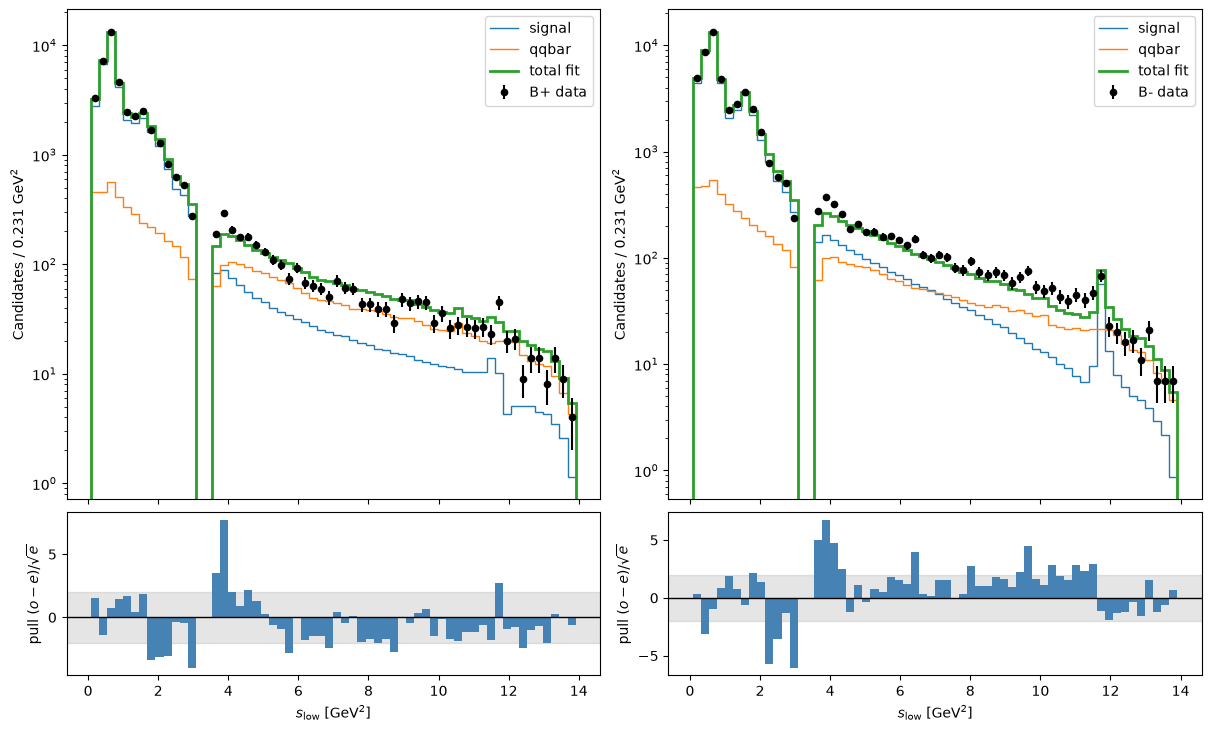

In [18]:
fit_session.plot_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="low",
    bins=60, show_components=True, show_pulls=True, projection_size=1_000_000, log_scale=True
)


array([[<Axes: ylabel='Candidates / 0.256 GeV$^2$'>,
        <Axes: ylabel='Candidates / 0.256 GeV$^2$'>],
       [<Axes: xlabel='$s_{\\mathrm{high}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>,
        <Axes: xlabel='$s_{\\mathrm{high}}$ [GeV$^2$]', ylabel='pull $(o-e)/\\sqrt{e}$'>]],
      dtype=object)

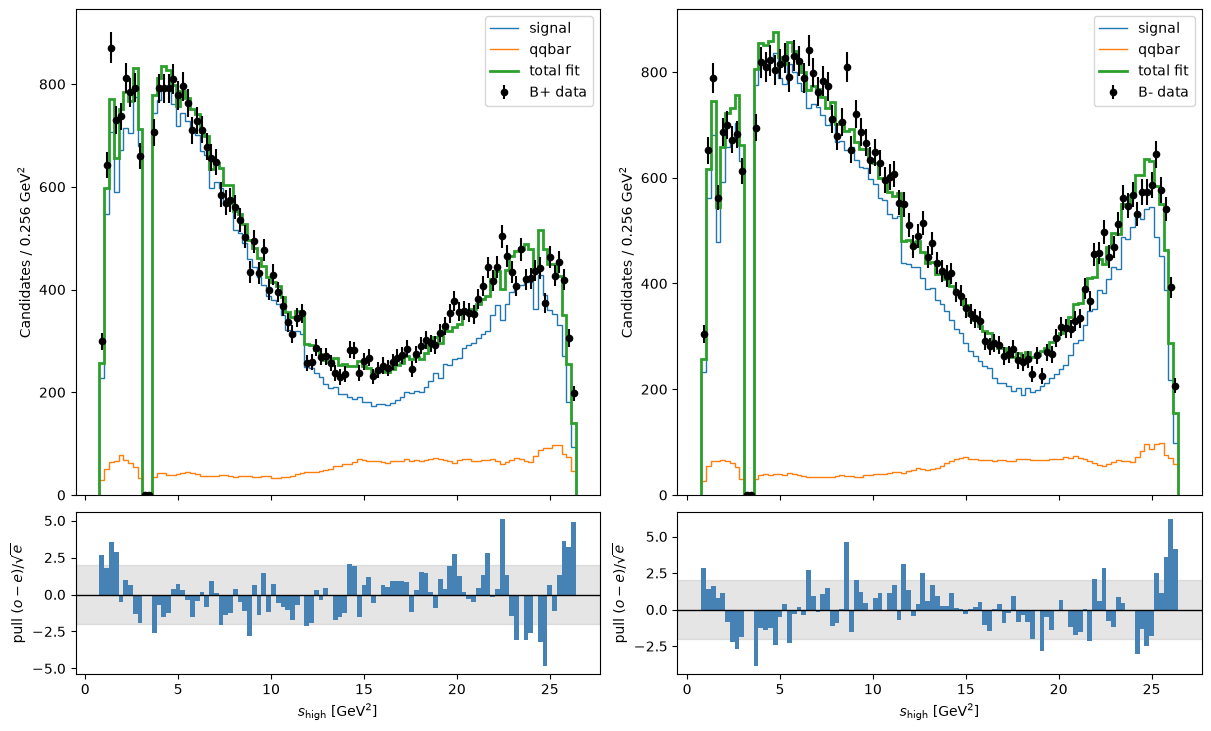

In [19]:
fit_session.plot_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="high",
    bins=100, show_components=True, show_pulls=True, projection_size=1_000_000
)


## Goodness-of-fit

Chi2 binado de Pearson no plano Square-Dalitz dobrado `(m', theta')` (mesmo par/convenção
`SQDP_PAIR`/`folded=True` usado para ACC e background acima), por carga -- ver
`docs/goodness_of_fit.md` para a leitura de `dof_min`/`dof_max`/`p_value_min`/`p_value_max`: como
os parâmetros vêm de um ajuste de máxima verossimilhança não-binado, o número exato de graus de
liberdade não é conhecido, e o resultado reporta as duas cotas de Williams (Sec. 3.1) em vez de um
único par dof/p-value potencialmente errado.

In [20]:
gof_square_dalitz = fit_session.goodness_of_fit_chi2(
    result, square_dalitz=True, folded=True,
    mother_mass=MOTHER_MASS, masses=DAUGHTER_MASSES, pair=SQDP_PAIR,
    bins=25,
)
for charge, res in gof_square_dalitz.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  "
          f"p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")


plus: chi2=1510.9  n_bins=625  n_free_parameters=43
       dof in [581, 624]  p-value in [6.529e-84, 2.736e-75]
minus: chi2=1693.8  n_bins=625  n_free_parameters=43
       dof in [581, 624]  p-value in [2.703e-109, 1.312e-99]


### Mapa de resíduos no Dalitz Plot (Square-Dalitz)

`(observado - esperado) / sqrt(esperado)` por bin `(m', theta')`, mesma grade usada no chi2 acima
(`res.pulls`/`res.edges` de `BinnedChi2Result`). Bins sem eventos esperados (`expected <= 0`)
aparecem em branco (`nan`, excluídos do chi2). Um painel por carga, escala de cor divergente
centrada em zero.

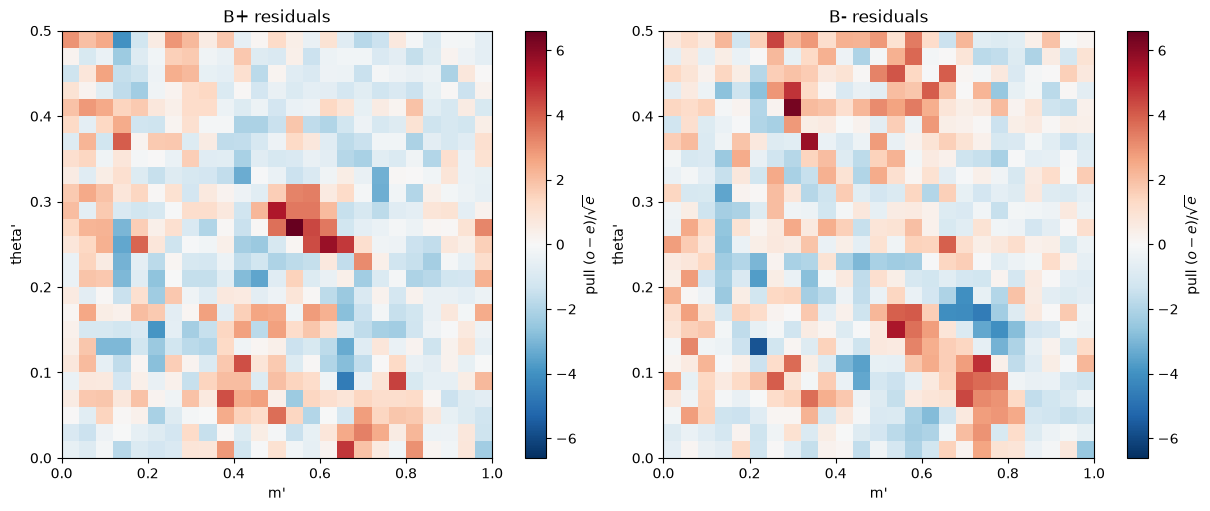

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
pull_max = max(
    np.nanmax(np.abs(res.pulls)) for res in gof_square_dalitz.values()
)
for ax, (charge, res) in zip(axes, gof_square_dalitz.items()):
    mp_edges, tp_edges = res.edges
    mesh = ax.pcolormesh(
        mp_edges, tp_edges, res.pulls.T,
        cmap="RdBu_r", vmin=-pull_max, vmax=pull_max, shading="flat",
    )
    ax.set_xlabel("m'")
    ax.set_ylabel("theta'")
    ax.set_title(f"B{'+' if charge == 'plus' else '-'} residuals")
    fig.colorbar(mesh, ax=ax, label=r"pull $(o-e)/\sqrt{e}$")


Chi2 binado 1D na projeção dobrada `s_low` (mesma convenção da seção anterior), por carga.

In [22]:
gof_s_low = fit_session.goodness_of_fit_projection(
    result, variable="s13", partner_variable="s23", folded=True, fold_side="low", bins=60,
)
for charge, res in gof_s_low.items():
    print(f"{charge}: chi2={res.chi2:.1f}  n_bins={res.n_bins}  n_free_parameters={res.n_free_parameters}")
    print(f"       dof in [{res.dof_min}, {res.dof_max}]  "
          f"p-value in [{res.p_value_min:.4g}, {res.p_value_max:.4g}]")


plus: chi2=228.4  n_bins=58  n_free_parameters=43
       dof in [14, 57]  p-value in [8.144e-41, 2.214e-22]
minus: chi2=328.8  n_bins=58  n_free_parameters=43
       dof in [14, 57]  p-value in [1.112e-61, 7.095e-40]


## Observações sobre a comparação

O ajuste converge (`valid=True`) a partir exatamente dos valores de partida do
`GenFit3piCP_R2_415489.cc`. Com as classes nativas do pacote, todos os 46 parâmetros do modelo
(33 coeficientes + 10 massas/larguras, mais o `rho0(770).dx` de referência) batem com o log do
Laura++ com *pull* abaixo de 0.4 sigma -- a maioria abaixo de 0.2 -- e as fit fractions por carga
batem a poucas centenas de um percentual (ver as tabelas acima). A tabela de $A_{CP}$/assimetria de
fit fraction também bate bem, uma vez corrigida a rotulagem (ver abaixo): a versão anterior deste
notebook comparava a assimetria de fit fraction calculada aqui contra a coluna errada do log
(`ACP for component ...`, uma grandeza diferente ao nível de coeficiente, em vez de `Fit Fraction
asymmetry for component ...`) -- as duas tabelas de assimetria acima agora usam cada uma a coluna
correta do log.

### Histórico da investigação

Uma versão anterior deste notebook (antes da API nativa existir) construía
`plus_efficiency`/`qqbar_plus_shape`/etc. diretamente com
`SquareDalitzHistogramEfficiency`/`SquareDalitzHistogramBackground` do pacote, sem interpolar e
sem dividir o background pelo jacobiano `(m',theta') -> (s13,s23)` -- isso produzia *pulls* de
vários sigma e um déficit de ~2x num bin estreito perto do pico do `rho(770)` em `s13`. Antes de
achar essa causa, uma bateria de outras hipóteses foi descartada com evidência numérica direta
(reprodutível fora deste notebook, comparando contra o C++ do Laura++ em
`/home/juan-leite/Work/Laura-3.8.0/Laura++/src/`):

- **Mínimo local**: descartado. `fit_multistart` com 6 pontos de partida aleatórios + o padrão
  convergiu, em 5 dos 6 casos, para exatamente o mesmo NLL.
- **Sub-amostragem de Monte Carlo nas projeções**: descartada. A fração de probabilidade prevista
  no bin de pico de `s13` ficava estável entre 250 mil, 1 milhão e 3 milhões de eventos de
  projeção.
- **Resolução/malha de normalização**: descartada. `normalization_method="square-dalitz"` (várias
  resoluções) e `normalization_method="gauss-legendre"` (grade adaptativa de ~1.76 milhões de
  pontos, refinada automaticamente em torno de `omega(782)`/`chi_c0` no plano `(m13, m23)`) davam
  resultados praticamente idênticos entre si.
- **Fórmulas de lineshape/spin/barreira**: verificadas linha a linha contra o Laura++ e batiam
  exatamente (`SigmaPole` vs. `LauPoleRes.cc`; `GounarisSakurai` vs. `LauGounarisSakuraiRes.cc`;
  `RelativisticBreitWigner` vs. `LauRelBreitWignerRes.cc`; barreira Blatt-Weisskopf "primed" vs.
  `LauBlattWeisskopfFactor.cc`; fator de spin Zemach vs.
  `LauAbsResonance::calcZemachSpinFactor`/`calcLegendrePoly`). Massas/larguras/spins de partida
  também conferidos um a um contra `LauResonanceMaker.cc`.

Ou seja: a causa não estava no otimizador, na quadratura de normalização nem nas fórmulas de
amplitude -- estava especificamente em como os histogramas de ACC/background eram lidos e
avaliados, o único ponto não coberto por essa verificação. a API nativa corrige
os dois problemas: A opção `interpolation="linear"` reproduz a interpolação bilinear
`Lau2DHistDP::interpolateXY` do Laura++ (em vez de busca pelo bin mais próximo), e
a opção `divide_jacobian=True` divide o valor lido do histograma de background pelo jacobiano
`square_dalitz_jacobian` antes de usá-lo como densidade em `(s13, s23)` -- o histograma armazena
uma densidade em `(m', theta')`, e o jacobiano entre as duas parametrizações varia ponto a ponto
pelo Dalitz Plot, então omiti-lo introduzia um viés de forma dependente de onde no DP o evento
cai, não uma constante global absorvível por `normalize_components`.